In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('phishing_site_urls.csv')

In [3]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [4]:
df.shape

(549346, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [6]:

df.isnull().sum()

URL      0
Label    0
dtype: int64

In [7]:
# Used to count the amount of good/bad urls
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

## Data Cleaning
Almost none of the dataset URLs include a scheme (`http://` / `https://`), and the few that do are all labelled bad. Real links always carry a scheme, so leaving it in teaches the model that `https` means phishing. The scheme is stripped here, and the exact same `normalize_url` is applied by the API before inference so training and serving see identical input.

In [8]:
import re

SCHEME_RE = re.compile(r'^[a-zA-Z][a-zA-Z0-9+.-]*://')

def normalize_url(url):
    return SCHEME_RE.sub('', url.strip())

print('URLs with a scheme:', df.URL.str.match(SCHEME_RE).sum())
df['URL'] = df.URL.map(normalize_url)

URLs with a scheme: 129


In [9]:
# Duplicate URLs would leak between the train and test sets and inflate accuracy
print('Duplicate URLs:', df.duplicated(subset='URL').sum())
print('URLs with conflicting labels:', (df.groupby('URL').Label.nunique() > 1).sum())
df = df.drop_duplicates(subset='URL').reset_index(drop=True)
df.Label.value_counts()

Duplicate URLs: 42156


URLs with conflicting labels: 1


Label
good    392897
bad     114293
Name: count, dtype: int64

In [10]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
from nltk.tokenize import RegexpTokenizer

In [12]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [13]:
#0 element of the URL section of db
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [14]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [15]:
# Tokenize all the URLs
df['text_tokenized'] = df.URL.map(lambda t: tokenizer.tokenize(t))

In [16]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [17]:
from nltk.stem.snowball import SnowballStemmer

In [18]:
stemmer = SnowballStemmer('english')

In [19]:
# Take each tokenized into stems
df['text_stemmed'] = df['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l] )

In [20]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [21]:
# Create new column
df['text'] = df['text_stemmed'].map(lambda l: ' '.join(l))

In [22]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [23]:
# Differentiate between good/bad sites
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [24]:
# Show the good sites
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [25]:
# Makes a word cloud to recognize how many times a word is used
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0,16.0), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'com', 'http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size,
                    random_state = 42,
                    mask = mask)
    wordcloud.generate(text)

    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,
                                   'verticalalignment': 'bottom'})

    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'green', 
                                   'verticalalignment': 'bottom'})

    plt.axis('off');
    plt.tight_layout()

In [26]:
all_text = ' '.join(good_sites['text'].tolist())

In [27]:
from wordcloud import WordCloud

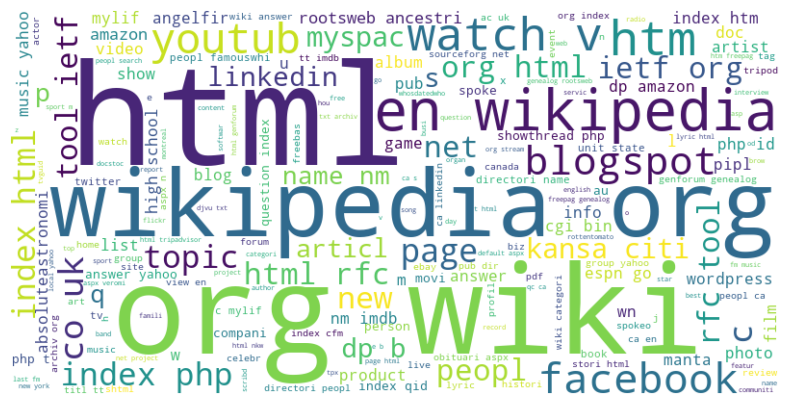

In [28]:
# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Show word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [29]:
all_text = ' '.join(bad_sites['text'].tolist())

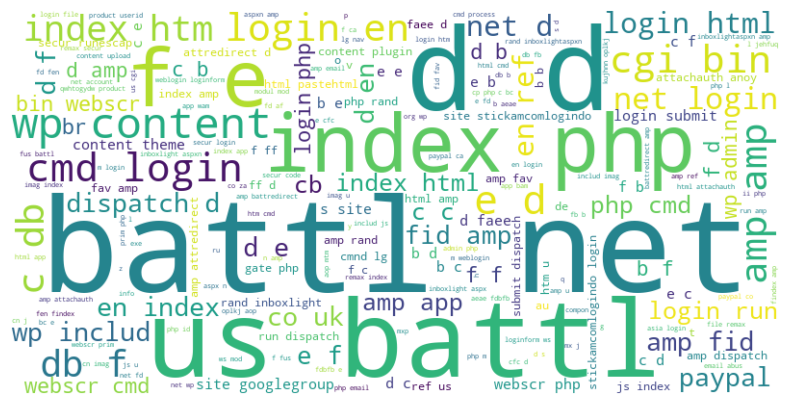

In [30]:
# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Show word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [31]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


## Vectorization

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [33]:
# Split before vectorizing so the vocabulary is learned from training data only
x_train_text, x_test_text, y_train, y_test = train_test_split(
    df.text, df.Label, test_size=0.2, stratify=df.Label, random_state=42
)

In [34]:
# Convert to vectors
cv = CountVectorizer()
x_train = cv.fit_transform(x_train_text)
x_test = cv.transform(x_test_text)
x_train.shape

(405752, 300230)

## Model Training

In [35]:
from sklearn.linear_model import LogisticRegression

# max_iter raised so lbfgs converges (the default of 100 stopped early)
l_model = LogisticRegression(max_iter=2000)
l_model.fit(x_train, y_train)
print('Iterations used:', l_model.n_iter_[0])

Iterations used: 97


## Evaluation

In [36]:
# Accuracy of Logistic Regression model
print('Test accuracy: ', l_model.score(x_test, y_test))
print('Train accuracy:', l_model.score(x_train, y_train))

Test accuracy:  0.965308858613143


Train accuracy: 0.9781122459039019


              precision    recall  f1-score   support

         bad     0.9649    0.8780    0.9194     22859
        good     0.9654    0.9907    0.9779     78579

    accuracy                         0.9653    101438
   macro avg     0.9652    0.9344    0.9486    101438
weighted avg     0.9653    0.9653    0.9647    101438



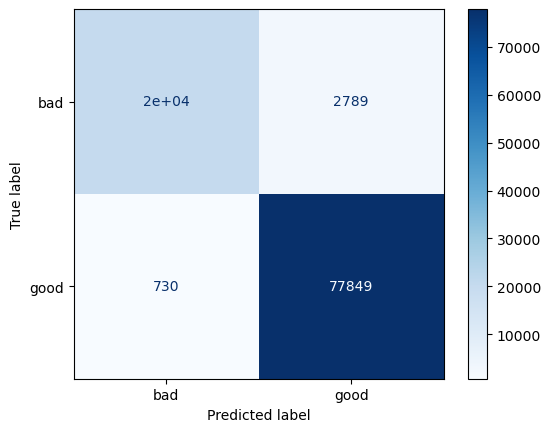

In [37]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = l_model.predict(x_test)
print(classification_report(y_test, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

In [38]:
# Tokens that push hardest toward each class (positive coefficients favour 'good')
coefs = pd.Series(l_model.coef_[0], index=cv.get_feature_names_out()).sort_values()
pd.DataFrame({
    'bad_token': coefs.head(15).index, 'bad_weight': coefs.head(15).values.round(2),
    'good_token': coefs.tail(15).index[::-1], 'good_weight': coefs.tail(15).values[::-1].round(2),
})

,bad_token,bad_weight,good_token,good_weight
0,paypal,-6.75,torrentz,6.20
1,pastehtml,-6.53,peopl,4.24
2,nwww,-5.75,docstoc,4.22
3,login,-5.40,mylif,4.16
4,dropbox,-5.15,findagrav,4.13
5,mxp,-5.13,myspac,4.11
6,includ,-4.99,photobucket,4.08
7,exe,-4.88,census,4.00
8,webscr,-4.81,spoke,3.91
9,rel,-4.79,theregist,3.88


In [39]:
# Sanity check on real-world style URLs, run through the same pipeline the API uses
def predict_url(url):
    tokens = tokenizer.tokenize(normalize_url(url))
    text = ' '.join(stemmer.stem(t) for t in tokens)
    proba = l_model.predict_proba(cv.transform([text]))[0]
    return dict(zip(l_model.classes_, proba))['bad']

samples = [
    'https://www.google.com',
    'https://github.com/login',
    'https://en.wikipedia.org/wiki/Phishing',
    'https://stackoverflow.com/questions/123',
    'http://paypal-secure-login.verify-account.xyz/update.php',
    'http://192.168.10.5/bank/login.html',
    'https://appleid.apple.com.verify-id.ru/signin',
]
pd.DataFrame({'url': samples, 'phishing_probability': [round(predict_url(u), 3) for u in samples]})

,url,phishing_probability
0,https://www.google.com,0.162
1,https://github.com/login,0.928
2,https://en.wikipedia.org/wiki/Phishing,0.000
3,https://stackoverflow.com/questions/123,0.064
4,http://paypal-secure-login.verify-account.xyz/...,1.000
5,http://192.168.10.5/bank/login.html,0.993
6,https://appleid.apple.com.verify-id.ru/signin,1.000


## Export
The vectorizer and model are saved together so the API always loads a matching pair.

In [40]:
import joblib

joblib.dump(cv, 'phishing_api/vectorizer.pkl')
joblib.dump(l_model, 'phishing_api/phishing.pkl')

['phishing_api/phishing.pkl']